# transformar audios a espectrogramas

In [ ]:
!pip install -q librosa
!pip install -q opencv-python
print("listo!")


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\ianmu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


listo!



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\ianmu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### leer metadatos y audios

In [ ]:
import os
import shutil
import pandas as pd

# rutas de entrada y salida
ESC50_META = "meta/esc50.csv"
ESC50_AUDIO = "audio/"
OUTPUT_DIR = "ESC-50-organized/"

# leer metadatos
meta = pd.read_csv(ESC50_META)

# crear carpeta base de salida si no existe
os.makedirs(OUTPUT_DIR, exist_ok=True)

# recorrer cada fila del CSV
for _, row in meta.iterrows():
    filename = row["filename"]
    category = row["category"]

    # carpeta destino segun categoria
    class_dir = os.path.join(OUTPUT_DIR, category)
    os.makedirs(class_dir, exist_ok=True)

    #ruta origen y destino
    src = os.path.join(ESC50_AUDIO, filename)
    dst = os.path.join(class_dir, filename)

    #copiar archivo si existe
    if os.path.exists(src):
        shutil.copy(src, dst)
    else:
        print(f"No se encontró: {src}")

print("Organización completada.")


Organización completada.


### hacer subcarpetas por categoria y hacer espectrogramas a 3 canales RGB de

1.   List item
2.   List item

224x224

In [ ]:
import os

input_dir = "ESC-50-organized"
output_dir = "spectrograms_224"
os.makedirs(output_dir, exist_ok=True)

files = os.listdir(input_dir)


In [ ]:
import os
import librosa
import numpy as np
import cv2

input_dir = "ESC-50-organized"
output_dir = "spectrograms_224"
os.makedirs(output_dir, exist_ok=True)

#procesar por clase (subcarpetas) y por archivo .wav dentro de cada una
for class_name in sorted(os.listdir(input_dir)):
    class_in = os.path.join(input_dir, class_name)
    if not os.path.isdir(class_in):
        continue
    class_out = os.path.join(output_dir, class_name)
    os.makedirs(class_out, exist_ok=True)

    for file in sorted(os.listdir(class_in)):
        if not file.lower().endswith(".wav"):
            continue

        src_path = os.path.join(class_in, file)
        try:
            y, sr = librosa.load(src_path, sr=22050)
        except Exception as e:
            print(f"Error loading {src_path}: {e}")
            continue

        #generar Mel-spectrograma
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)

        #normalizar a [0, 255]
        img = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min() + 1e-8)
        img = np.uint8(255 * img)

        # aplicar mapa de color (magma) y redimensionar a 224x224
        img_color = cv2.applyColorMap(img, cv2.COLORMAP_MAGMA)
        img_resized = cv2.resize(img_color, (224, 224))

        # guardar imagen RGB dentro de la carpeta de la clase
        out_name = file.replace(".wav", ".png")
        out_path = os.path.join(class_out, out_name)
        cv2.imwrite(out_path, cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))

print("Espectrogramas guardados en:", output_dir)

Espectrogramas guardados en: spectrograms_224


### dividir en train, val, test con proporciones 70%, 15%, 15% manteniendo distribucion de clases (se mueven los .png de las subcarpetas, no se copian)

In [ ]:
import os
import random
import shutil

random.seed(42)

base_dir = "spectrograms_224"
output_dir = "spectrograms_split_224"
splits = ["train", "val", "test"]
ratios = [0.7, 0.15, 0.15]
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tiff")

#crear carpetas top-level
for split in splits:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

def _split_and_transfer(file_list, src_dir, class_name, move=True):
    random.shuffle(file_list)
    n_total = len(file_list)
    n_train = int(n_total * ratios[0])
    n_val = int(n_total * ratios[1])
    train_files = file_list[:n_train]
    val_files = file_list[n_train:n_train + n_val]
    test_files = file_list[n_train + n_val:]
    counts = {}
    for split, files in zip(splits, [train_files, val_files, test_files]):
        dst_dir = os.path.join(output_dir, split, class_name)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in files:
            src = os.path.join(src_dir, fname)
            dst = os.path.join(dst_dir, fname)
            try:
                if move:
                    shutil.move(src, dst)
                else:
                    shutil.copy2(src, dst)
            except Exception as e:
                print(f"Error transferring {src} -> {dst}: {e}")
        counts[split] = len(files)
    return n_total, counts["train"], counts["val"], counts["test"]

#detectar si hay subcarpetas por clase
entries = [e for e in sorted(os.listdir(base_dir)) if not e.startswith(".")]
has_class_dirs = any(os.path.isdir(os.path.join(base_dir, e)) for e in entries)

summary = []
if has_class_dirs:
    for class_name in entries:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        images = [f for f in sorted(os.listdir(class_path)) if f.lower().endswith(IMG_EXTS)]
        if not images:
            continue
        totals = _split_and_transfer(images, class_path, class_name, move=True)
        summary.append((class_name,) + totals)
else:
    images = [f for f in sorted(os.listdir(base_dir)) if f.lower().endswith(IMG_EXTS)]
    if images:
        totals = _split_and_transfer(images, base_dir, "class0", move=True)
        summary.append(("class0",) + totals)

print("Resumen por clase (class, total, n_train, n_val, n_test):")
for row in summary:
    print(row)

#comprobar si hay duplicados entre splits (por nombre de archivo) (ojala que no)
from pathlib import Path
train_files = {p.name for p in Path(output_dir, "train").rglob("*") if p.is_file()}
val_files = {p.name for p in Path(output_dir, "val").rglob("*") if p.is_file()}
test_files = {p.name for p in Path(output_dir, "test").rglob("*") if p.is_file()}
print("duplicates trainval:", len(train_files & val_files))
print("duplicates traintest:", len(train_files & test_files))
print("duplicates valtest:", len(val_files & test_files))

print("División completada y guardada en:", output_dir)

Resumen por clase (class, total, n_train, n_val, n_test):
duplicates trainval: 0
duplicates traintest: 0
duplicates valtest: 0
División completada y guardada en: spectrograms_split_224


# Modelo A
## Modelo A base

In [ ]:
!python -m pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126


In [ ]:
!pip3 install -q torch torchvision --index-url https://download.pytorch.org/whl/cu126


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\ianmu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import sys
import torch

print("Python executable:", sys.executable)
print("torch.__version__:", getattr(torch, "__version__", None))
print("torch.version.cuda:", getattr(torch.version, "cuda", None))
print("torch.cuda.is_available():", torch.cuda.is_available())
try:
    print("cuda device count:", torch.cuda.device_count())
except Exception as e:
    print("cuda device count error:", e)

Python executable: C:\Users\ianmu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
torch.__version__: 2.9.0+cu126
torch.version.cuda: 12.6
torch.cuda.is_available(): True
cuda device count: 1


In [ ]:

import os
import random
import argparse
import numpy as np

import torch #solo usamos torch como dice la instruccion y lo de sklearn es para metricas asi que estamos bien
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report


# Datos random según una seed

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


#LeNet-5(manual)

class LeNet5Base(nn.Module):
    def __init__(self, num_classes=50):
        super(LeNet5Base, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=2)
        self.pool1 = nn.AvgPool2d(2, 2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, 2)

        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)

        self.gap = nn.AdaptiveAvgPool2d((5, 5))
        self.fc1 = nn.Linear(120 * 5 * 5, 84)
        self.fc2 = nn.Linear(84, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:

#División en training, validation y test

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

In [ ]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

@torch.no_grad()
def test_and_report(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)
    acc = np.sum(np.diag(cm)) / np.sum(cm)
    return cm, report, acc

In [ ]:
#Helpers: data transforms
def get_transforms(augmented=False):
    # Base transforms (for val/test)
    base = [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]

    if not augmented:
        return transforms.Compose(base)

    # Define augmentations
    aug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomApply([
            transforms.RandomRotation(10),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
            transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
        ], p=0.8),
        transforms.ToTensor()
    ])
    return aug


In [ ]:

#Función para correr un experimento (una corrida) (augmented = False)
def run_experiment(data_dir, output_dir, run_name, num_classes=50, epochs=20, batch_size=32,
                   lr=1e-3, weight_decay=1e-5, augmented=False, seed=42, device='cuda'):
    set_seed(seed)
    device = torch.device(device)
    print(f"[Run {run_name}] Device: {device} | Augmented: {augmented} | Seed: {seed}")

    train_dir = os.path.join(data_dir, "train")
    val_dir   = os.path.join(data_dir, "val")
    test_dir  = os.path.join(data_dir, "test")

    transform_train = get_transforms(augmented=augmented)
    transform_eval = get_transforms(augmented=False)

    train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
    val_dataset = datasets.ImageFolder(val_dir, transform=transform_eval)
    test_dataset = datasets.ImageFolder(test_dir, transform=transform_eval)

    class_names = [c[0] for c in sorted(train_dataset.class_to_idx.items(), key=lambda x: x[1])]
    print(f"[Run {run_name}] Classes: {len(class_names)} | Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    model = LeNet5Base(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


    try:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3, verbose=True
        )
    except TypeError:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )


    best_val_loss = float('inf')
    best_epoch = -1
    best_state = None


    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{run_name}] Epoch {epoch}/{epochs} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "epoch": epoch,
                "class_to_idx": train_dataset.class_to_idx
            }
            os.makedirs(output_dir, exist_ok=True)
            ckpt_path = os.path.join(output_dir, f"best_{run_name}.pth")
            torch.save(best_state, ckpt_path)

    print(f"[{run_name}] Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")

    if best_state is not None:
        model.load_state_dict(best_state["model_state"])

    cm, report, test_acc = test_and_report(model, test_loader, device, class_names)

    final_dir = os.path.join(output_dir, f"final_{run_name}")
    os.makedirs(final_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(final_dir, "model_final.pth"))
    np.save(os.path.join(final_dir, "confusion_matrix.npy"), cm)
    with open(os.path.join(final_dir, "classification_report.txt"), "w") as f:
        f.write(report)


    return {
        "run_name": run_name,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "report": report,
        "confusion_matrix": cm,
        "history": history
    }

In [ ]:
#Función para correr los 5 experimentos con LeNet-5 (datos crudos)
def multiple_experiments_modelA(argv=None):
    parser = argparse.ArgumentParser()
    parser.add_argument("--data_dir", type=str, default="spectrograms_split_224", help="Folder with train/val/test subfolders")
    parser.add_argument("--output_dir", type=str, default="results_lenet_a", help="Where to save checkpoints and outputs")
    parser.add_argument("--num_classes", type=int, default=50)
    parser.add_argument("--epochs", type=int, default=150)
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight_decay", type=float, default=1e-5)
    parser.add_argument("--runs", type=int, default=5, help="Number of runs (>=5 recommended)")
    parser.add_argument("--device", type=str, default="cuda", help="cuda or cpu")
    parser.add_argument("--seed_start", type=int, default=42, help="starting seed for runs (will increment)")

    import sys
    if argv is not None:
        args = parser.parse_args(argv)
    else:
        if 'ipykernel' in sys.modules:
            args, _ = parser.parse_known_args()
        else:
            args = parser.parse_args()

    try:
        import torch
        if isinstance(args.device, str) and args.device.lower().startswith("cuda"):
            if not torch.cuda.is_available():
                print("Warning: CUDA requested but not available (torch.cuda.is_available() is False). Falling back to CPU.")
                args.device = "cpu"
    except Exception:
        args.device = "cpu"

    os.makedirs(args.output_dir, exist_ok=True)

    aggregate_results = []
    for i in range(args.runs):
        seed = args.seed_start + i
        run_name = f"lenet_a_base_run{i+1}_s{seed}"
        out = run_experiment(
            data_dir=args.data_dir,
            output_dir=args.output_dir,
            run_name=run_name,
            num_classes=args.num_classes,
            epochs=args.epochs,
            batch_size=args.batch_size,
            lr=args.lr,
            weight_decay=args.weight_decay,
            seed=seed,
            device=args.device
        )
        aggregate_results.append(out)

    aggregate_results = sorted(aggregate_results, key=lambda x: x["test_acc"], reverse=True)
    best = aggregate_results[0]
    summary_path = os.path.join(args.output_dir, f"summary_base.txt")
    with open(summary_path, "w") as f:
        f.write("Summary of runs (sorted by test_acc desc):\n\n")
        for r in aggregate_results:
            f.write(f"{r['run_name']}: test_acc={r['test_acc']:.4f}, best_val_loss={r['best_val_loss']:.4f}, best_epoch={r['best_epoch']}\n")
        f.write("\nBest overall:\n")
        f.write(str(best))

    print("All runs finished. Summary saved to:", summary_path)

    return aggregate_results


results = multiple_experiments_modelA()

[Run lenet_a_base_run1_s42] Device: cuda | Augmented: False | Seed: 42
[Run lenet_a_base_run1_s42] Classes: 50 | Train size: 1400 | Val size: 300 | Test size: 300
[lenet_a_base_run1_s42] Epoch 1/150 | Train loss: 3.8490 acc: 0.0386 | Val loss: 3.7224 acc: 0.0567
[lenet_a_base_run1_s42] Epoch 1/150 | Train loss: 3.8490 acc: 0.0386 | Val loss: 3.7224 acc: 0.0567
[lenet_a_base_run1_s42] Epoch 2/150 | Train loss: 3.5216 acc: 0.0814 | Val loss: 3.3237 acc: 0.1400
[lenet_a_base_run1_s42] Epoch 2/150 | Train loss: 3.5216 acc: 0.0814 | Val loss: 3.3237 acc: 0.1400
[lenet_a_base_run1_s42] Epoch 3/150 | Train loss: 3.1991 acc: 0.1521 | Val loss: 3.0183 acc: 0.1700
[lenet_a_base_run1_s42] Epoch 3/150 | Train loss: 3.1991 acc: 0.1521 | Val loss: 3.0183 acc: 0.1700
[lenet_a_base_run1_s42] Epoch 4/150 | Train loss: 2.8391 acc: 0.2193 | Val loss: 2.6535 acc: 0.2933
[lenet_a_base_run1_s42] Epoch 4/150 | Train loss: 2.8391 acc: 0.2193 | Val loss: 2.6535 acc: 0.2933
[lenet_a_base_run1_s42] Epoch 5/150 |

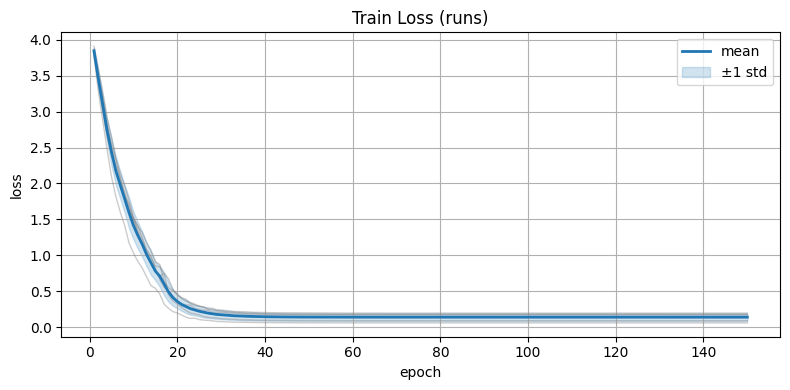

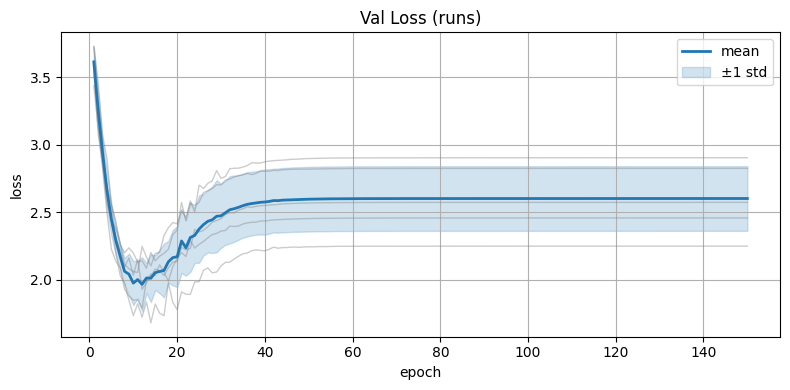

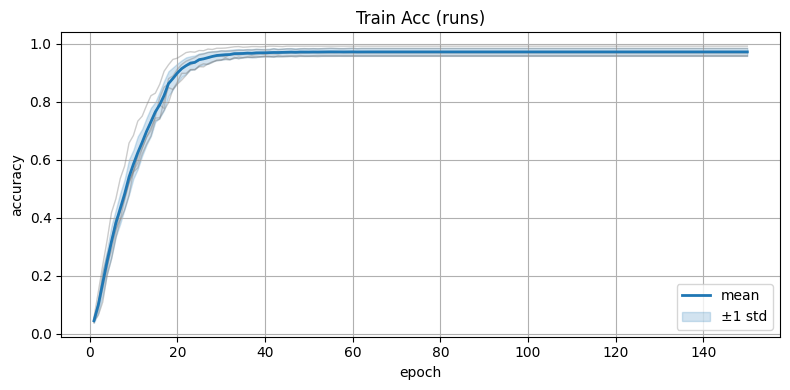

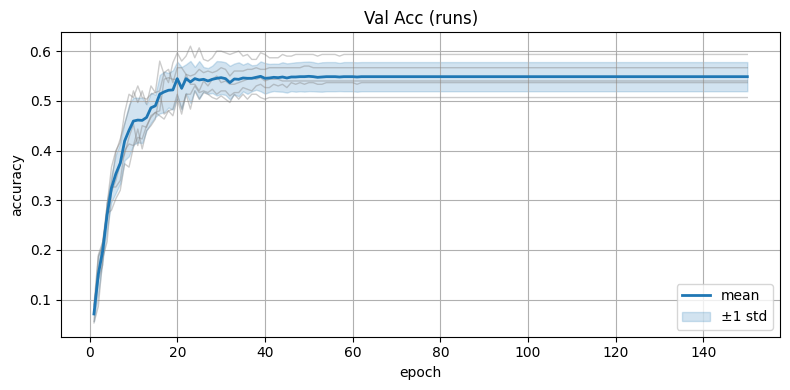

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

out_dir = "results_plots"
os.makedirs(out_dir, exist_ok=True)

histories = [r['history'] for r in results]
n_runs = len(histories)
epochs = len(histories[0]['train_loss'])

train_loss = np.array([h['train_loss'] for h in histories])
val_loss   = np.array([h['val_loss'] for h in histories])
train_acc  = np.array([h['train_acc'] for h in histories])
val_acc    = np.array([h['val_acc'] for h in histories])
x = np.arange(1, epochs+1)

def plot_with_mean(ax, arr, title, ylabel, filename):
    for row in arr:
        ax.plot(x, row, color='gray', alpha=0.4, linewidth=1)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(x, mean, color='tab:blue', linewidth=2, label='mean')
    ax.fill_between(x, mean-std, mean+std, color='tab:blue', alpha=0.2, label='±1 std')
    ax.set_title(title)
    ax.set_xlabel('epoch')
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, filename), dpi=150)

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean(ax, train_loss, "Train Loss (runs)", "loss", "train_loss.png")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean(ax, val_loss, "Val Loss (runs)", "loss", "val_loss.png")
plt.show()

# Acc figure
fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean(ax, train_acc, "Train Acc (runs)", "accuracy", "train_acc.png")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean(ax, val_acc, "Val Acc (runs)", "accuracy", "val_acc.png")
plt.show()

## Model A Aumentado

In [ ]:
res_aug = run_experiment(
    data_dir="spectrograms_split_224",
    output_dir="results_lenet_a_aug",
    run_name="lenet_a_aug_run1",
    num_classes=50,
    epochs=5,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-5,
    augmented=True,
    seed=42,
    device="cuda"
)
print("Test acc:", res_aug["test_acc"])


[Run lenet_a_aug_run1] Device: cuda | Augmented: True | Seed: 42
[Run lenet_a_aug_run1] Classes: 50 | Train size: 1400 | Val size: 300 | Test size: 300
[lenet_a_aug_run1] Epoch 1/5 | Train loss: 3.8379 acc: 0.0357 | Val loss: 3.7079 acc: 0.0500
[lenet_a_aug_run1] Epoch 1/5 | Train loss: 3.8379 acc: 0.0357 | Val loss: 3.7079 acc: 0.0500
[lenet_a_aug_run1] Epoch 2/5 | Train loss: 3.5742 acc: 0.0707 | Val loss: 3.3814 acc: 0.0900
[lenet_a_aug_run1] Epoch 2/5 | Train loss: 3.5742 acc: 0.0707 | Val loss: 3.3814 acc: 0.0900
[lenet_a_aug_run1] Epoch 3/5 | Train loss: 3.2319 acc: 0.1207 | Val loss: 3.0605 acc: 0.1500
[lenet_a_aug_run1] Epoch 3/5 | Train loss: 3.2319 acc: 0.1207 | Val loss: 3.0605 acc: 0.1500
[lenet_a_aug_run1] Epoch 4/5 | Train loss: 2.9692 acc: 0.1643 | Val loss: 2.8051 acc: 0.1967
[lenet_a_aug_run1] Epoch 4/5 | Train loss: 2.9692 acc: 0.1643 | Val loss: 2.8051 acc: 0.1967
[lenet_a_aug_run1] Epoch 5/5 | Train loss: 2.7281 acc: 0.2314 | Val loss: 2.4679 acc: 0.2867
[lenet_a_au

In [ ]:
aggregate_aug = []
n_runs = 5
for i in range(n_runs):
    seed = 42 + i
    run_name = f"lenet_a_aug_run{i+1}_s{seed}"
    out = run_experiment(
        data_dir="spectrograms_split_224",
        output_dir="results_lenet_a_aug",
        run_name=run_name,
        num_classes=50,
        epochs=150,
        batch_size=32,
        lr=1e-3,
        weight_decay=1e-5,
        augmented=True,
        seed=seed,
        device="cuda"
    )
    aggregate_aug.append(out)

results = aggregate_aug

[Run lenet_a_aug_run1_s42] Device: cuda | Augmented: True | Seed: 42
[Run lenet_a_aug_run1_s42] Classes: 50 | Train size: 1400 | Val size: 300 | Test size: 300
[lenet_a_aug_run1_s42] Epoch 1/150 | Train loss: 3.8379 acc: 0.0357 | Val loss: 3.7079 acc: 0.0500
[lenet_a_aug_run1_s42] Epoch 1/150 | Train loss: 3.8379 acc: 0.0357 | Val loss: 3.7079 acc: 0.0500
[lenet_a_aug_run1_s42] Epoch 2/150 | Train loss: 3.5742 acc: 0.0707 | Val loss: 3.3814 acc: 0.0900
[lenet_a_aug_run1_s42] Epoch 2/150 | Train loss: 3.5742 acc: 0.0707 | Val loss: 3.3814 acc: 0.0900
[lenet_a_aug_run1_s42] Epoch 3/150 | Train loss: 3.2319 acc: 0.1207 | Val loss: 3.0605 acc: 0.1500
[lenet_a_aug_run1_s42] Epoch 3/150 | Train loss: 3.2319 acc: 0.1207 | Val loss: 3.0605 acc: 0.1500
[lenet_a_aug_run1_s42] Epoch 4/150 | Train loss: 2.9692 acc: 0.1643 | Val loss: 2.8051 acc: 0.1967
[lenet_a_aug_run1_s42] Epoch 4/150 | Train loss: 2.9692 acc: 0.1643 | Val loss: 2.8051 acc: 0.1967
[lenet_a_aug_run1_s42] Epoch 5/150 | Train loss:

Gráficas guardadas en: results_lenet_a_aug\plots_augmented_history.png


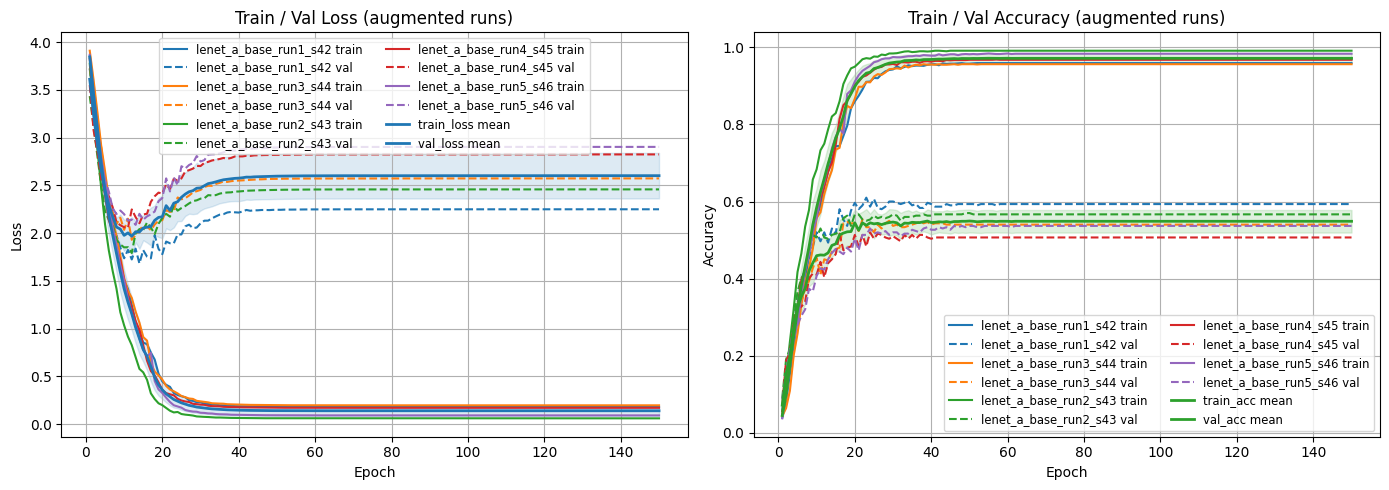

In [ ]:
#esta es una sola funcion que recupera info y la plottea

import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import torch

OUT_DIR = "results_lenet_a_aug"

def load_history_file(path):
    try:
        if path.endswith(".json"):
            with open(path, "r") as f:
                return json.load(f)
        if path.endswith(".npy") or path.endswith(".npz"):
            arr = np.load(path, allow_pickle=True)
            try:
                return arr.tolist()
            except Exception:
                return {k: arr[k].tolist() for k in arr.files}
        if path.endswith(".pth") or path.endswith(".pt"):
            d = torch.load(path, map_location="cpu")
            if isinstance(d, dict):
                if "history" in d and isinstance(d["history"], dict):
                    return d["history"]
                for k in ("train_loss","val_loss","train_acc","val_acc"):
                    if k in d:
                        return {k: d[k] for k in ("train_loss","val_loss","train_acc","val_acc") if k in d}
    except Exception:
        return None
    return None

def load_histories_from_disk(out_dir):
    histories = {}
    for p in glob.glob(os.path.join(out_dir, "**", "*history*.*"), recursive=True):
        h = load_history_file(p)
        if isinstance(h, dict) and h:
            histories[os.path.basename(p)] = h
    for p in glob.glob(os.path.join(out_dir, "best_*.pth")) + glob.glob(os.path.join(out_dir, "**", "best_*.pth"), recursive=True):
        h = load_history_file(p)
        if isinstance(h, dict) and h:
            histories[os.path.basename(p)] = h
    return histories

runs_list = None
if "aggregate_aug" in globals() and isinstance(globals()["aggregate_aug"], list) and globals()["aggregate_aug"]:
    runs_list = globals()["aggregate_aug"]
elif "results" in globals() and isinstance(globals()["results"], list) and globals()["results"]:
    runs_list = globals()["results"]

if runs_list is None:
    loaded = load_histories_from_disk(OUT_DIR)
    if loaded:
        runs_list = []
        for name, h in loaded.items():
            runs_list.append({"run_name": name, "history": h})
    else:
        print("No se encontraron resultados en memoria ni historiales en disco.")
        print("Asegúrate de ejecutar los runs en esta sesión (variable `aggregate_aug` o `results`)")
        print("o guarda la variable 'history' desde run_experiment en archivos '*history*.npy/.json' dentro de", OUT_DIR)
        raise SystemExit

normalized = []
for r in runs_list:
    if isinstance(r, dict) and "history" in r:
        h = r["history"]
        name = r.get("run_name", r.get("run_name", "run"))
    elif isinstance(r, dict) and all(k in r for k in ("train_loss","val_loss","train_acc","val_acc")):
        h = {k: r[k] for k in ("train_loss","val_loss","train_acc","val_acc")}
        name = r.get("run_name","run")
    else:
        h = r if isinstance(r, dict) else {}
        name = "run"
    for k in ("train_loss","val_loss","train_acc","val_acc"):
        if k in h:
            try:
                h[k] = np.array(h[k], dtype=float)
            except Exception:
                h[k] = np.array(list(h[k]), dtype=float) if hasattr(h[k], "__iter__") else np.array([float(h[k])])
    normalized.append({"run_name": name, "history": h})

plt.rcParams.update({"figure.max_open_warning": 0})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
colors = plt.cm.tab10.colors
same_length = True
lengths = []

for idx, r in enumerate(normalized):
    h = r["history"]
    name = r["run_name"]
    c = colors[idx % len(colors)]
    # Loss
    if "train_loss" in h and "val_loss" in h:
        ax1.plot(np.arange(1, len(h["train_loss"])+1), h["train_loss"], label=f"{name} train", color=c, linestyle='-')
        ax1.plot(np.arange(1, len(h["val_loss"])+1), h["val_loss"], label=f"{name} val", color=c, linestyle='--')
        lengths.append(len(h["train_loss"]))
    else:
        if "train_loss" in h:
            ax1.plot(np.arange(1, len(h["train_loss"])+1), h["train_loss"], label=f"{name} train", color=c, linestyle='-')
            lengths.append(len(h["train_loss"]))
        if "val_loss" in h:
            ax1.plot(np.arange(1, len(h["val_loss"])+1), h["val_loss"], label=f"{name} val", color=c, linestyle='--')
            lengths.append(len(h["val_loss"]))
    if "train_acc" in h and "val_acc" in h:
        ax2.plot(np.arange(1, len(h["train_acc"])+1), h["train_acc"], label=f"{name} train", color=c, linestyle='-')
        ax2.plot(np.arange(1, len(h["val_acc"])+1), h["val_acc"], label=f"{name} val", color=c, linestyle='--')
    else:
        if "train_acc" in h:
            ax2.plot(np.arange(1, len(h["train_acc"])+1), h["train_acc"], label=f"{name} train", color=c, linestyle='-')
        if "val_acc" in h:
            ax2.plot(np.arange(1, len(h["val_acc"])+1), h["val_acc"], label=f"{name} val", color=c, linestyle='--')

if len(lengths) > 1 and len(set(lengths)) != 1:
    same_length = False

if same_length and lengths:
    L = lengths[0]
    def collect(key):
        arrs = []
        for r in normalized:
            h = r["history"]
            if key in h and len(h[key]) == L:
                arrs.append(h[key])
        return np.vstack(arrs) if arrs else None
    for key, ax, ylabel, title in [
        ("train_loss", ax1, "Loss", "Train Loss (runs)"),
        ("val_loss", ax1, "Loss", "Validation Loss (runs)"),
        ("train_acc", ax2, "Accuracy", "Train Acc (runs)"),
        ("val_acc", ax2, "Accuracy", "Val Acc (runs)"),
    ]:
        mat = collect(key)
        if mat is not None and mat.shape[0] >= 2:
            mean = mat.mean(axis=0)
            std = mat.std(axis=0)
            epochs = np.arange(1, L+1)
            alpha = 0.15
            if "loss" in key:
                ax.fill_between(epochs, mean-std, mean+std, color='tab:blue', alpha=alpha)
                ax.plot(epochs, mean, color='tab:blue', linewidth=2, label=f"{key} mean")
            else:
                ax.fill_between(epochs, mean-std, mean+std, color='tab:green', alpha=alpha)
                ax.plot(epochs, mean, color='tab:green', linewidth=2, label=f"{key} mean")

ax1.set_title("Train / Val Loss (augmented runs)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)
ax1.legend(fontsize='small', ncol=2)

ax2.set_title("Train / Val Accuracy (augmented runs)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
ax2.legend(fontsize='small', ncol=2)

plt.tight_layout()

os.makedirs(OUT_DIR, exist_ok=True)
plot_path = os.path.join(OUT_DIR, "plots_augmented_history.png")
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
print("Gráficas guardadas en:", plot_path)
plt.show()

# Modelo B

## Modelo B base

In [ ]:

import os
import random
import argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

#Datos random según una seed. cada vez que se ejecuta el programa, da los mismos resultados
def set_seed(seed: int = 42):
    random.seed(seed) #le dice a python que empiece sus nums aleatorios siempre desde el mismo punto
    np.random.seed(seed) #hace lo mismo para numpy
    torch.manual_seed(seed) #hace lo mismo para torch
    torch.cuda.manual_seed_all(seed) #lo mismo pero para las tarjetas graficas gpu
    torch.backends.cudnn.deterministic = True #para que python use los mismos pasos para su calculos
    torch.backends.cudnn.benchmark = False #le dice a pytorch que no metodos diferentes para ver cual es el mas rapido


In [ ]:
#Definición de ResNet-18 (manual)
class BasicBlock(nn.Module):
    expansion = 1 #crea una pieza basica de red, es propio de resnet
    def __init__(self, in_planes, planes, stride=1, downsample=None):
        super().__init__()
        #in planes: capas de color entran. planes: cuantos canales saldran. stride: cuanto reduce el tamanno
        #de la imagen. 1 = igual. downsample: para ajustar tamannos. bias: false, no agrega un valor extra a cada res
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        #mide zonas de la imagen y detecta patrones. es la primera convolucion.

        self.bn1 = nn.BatchNorm2d(planes) #normaliza los numeros

        #segunda convolucion: igual a la primera, sin reducir tamanno
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample #guarda la funcion que se usara si  la imagen cambio de tamanno y hay que ajustarla
        #para poder sumarla despues

    def forward(self, x):
        identity = x #guarda una copia de x que es la copia del res anterior.
        out = F.relu(self.bn1(self.conv1(x))) #hace la primera convolucion y aplica relu: pasan los valores positivos y quita los negativos
        out = self.bn2(self.conv2(out)) #hace otra convolucion y una normalizacion. sin relu
        if self.downsample is not None: #si el tamanno de la imagen cambio, si se redujo, ajusta la copia identity para que tenga el mismo tamanno que out
            identity = self.downsample(x)
        out += identity  #suma el res nuevo con la identity. asi el bloque aprende la diferencia entre entrada y salida.

        out = F.relu(out) #vuelve a dejar los valores + y retorna el resultado
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=50): #tenemos 50 sonidos distintos.
        super().__init__()
        self.in_planes = 64 #el primer bloque usa 64 canales, es decir, colores de profundidad.

        #3: rgb, 64: canales de prof, kernel_size: 7
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)

        #normaliza, activa relu y hace maxpooling.
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        #Se construyen grupos de bloques residuales.
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        #Aplasta toda la info de cada canal en un solo promedio. pasa de 7x7 a un vector de 512.
        #luego la capa fully connected convierte los 512 vals en 50 salidas.
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        self._init_weights()


    #si hay cambio de tamanno o de canales, hace
    def _make_layer(self, planes, blocks, stride):
        downsample = None
        if stride != 1 or self.in_planes != planes:
          #si hay un cambio de tamanno, ajusta la entrada para que coincida con la salida
          #antes de sumarlas
            downsample = nn.Sequential(
                nn.Conv2d(self.in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

        #crea el primer bloque residual de una capa y reduce la imagen si hace falta
        layers = [BasicBlock(self.in_planes, planes, stride, downsample)]

        #actualiza el num de canales actuales al nuevo valor
        self.in_planes = planes

        #agrega los demas bloques residuales.
        for _ in range(1, blocks):

            layers.append(BasicBlock(self.in_planes, planes))
        return nn.Sequential(*layers)

    #le da a cada capa buenos valores iniciales, asi aprende mas rapido y no empieza con numeros raros
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    #
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        #cada una extrae caracteristicas mas complejas
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x) #resume todo en un vector de 512 num
        x = torch.flatten(x, 1) #aplana los datos de 2d a 1d
        x = self.fc(x) #produce 50 resultados
        return x

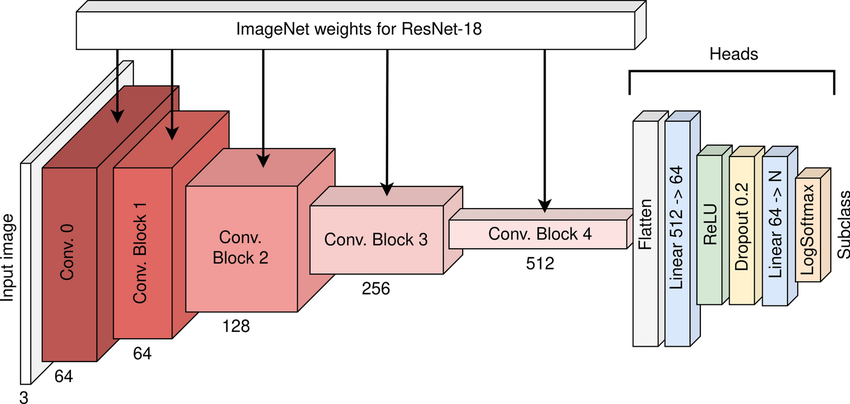

In [ ]:
#División en training, validation y test
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def test_and_report(model, loader, device, class_names):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)
    acc = np.sum(np.diag(cm)) / np.sum(cm)
    return cm, report, acc


In [ ]:
# Entrenamiento modelo B
def run_experiment_resnet(data_dir, output_dir, run_name, num_classes=50, epochs=20, batch_size=32,
                          lr=1e-3, weight_decay=1e-5, augmented=False, seed=42, device='cuda'):
    set_seed(seed)
    device = torch.device(device)
    print(f"[Run {run_name}] Device: {device} | Augmented: {augmented} | Seed: {seed}")

    train_dir = os.path.join(data_dir, "train")
    val_dir   = os.path.join(data_dir, "val")
    test_dir  = os.path.join(data_dir, "test")

    transform_train = get_transforms(augmented=augmented)
    transform_eval  = get_transforms(augmented=False)

    train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
    val_dataset   = datasets.ImageFolder(val_dir, transform=transform_eval)
    test_dataset  = datasets.ImageFolder(test_dir, transform=transform_eval)

    class_names = [c[0] for c in sorted(train_dataset.class_to_idx.items(), key=lambda x: x[1])]
    print(f"[Run {run_name}] Classes: {len(class_names)} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    model = ResNet18(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    try:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    except TypeError:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_loss, best_epoch, best_state = float('inf'), -1, None
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{run_name}] Epoch {epoch}/{epochs} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, best_epoch = val_loss, epoch
            best_state = {
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "epoch": epoch,
                "class_to_idx": train_dataset.class_to_idx
            }
            os.makedirs(output_dir, exist_ok=True)
            torch.save(best_state, os.path.join(output_dir, f"best_{run_name}.pth"))

    print(f"[{run_name}] Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")

    if best_state:
        model.load_state_dict(best_state["model_state"])

    cm, report, test_acc = test_and_report(model, test_loader, device, class_names)
    print(f"[{run_name}] Test acc: {test_acc:.4f}")

    final_dir = os.path.join(output_dir, f"final_{run_name}")
    os.makedirs(final_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(final_dir, "model_final.pth"))
    np.save(os.path.join(final_dir, "confusion_matrix.npy"), cm)
    with open(os.path.join(final_dir, "classification_report.txt"), "w") as f:
        f.write(report)

    return {
        "run_name": run_name,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "report": report,
        "confusion_matrix": cm,
        "history": history
    }

In [ ]:
#Función para correr los 5 experimentos con ResNet-18 (datos crudos)
def multiple_experiments_modelB(argv=None):
    parser = argparse.ArgumentParser()
    parser.add_argument("--data_dir", type=str, default="spectrograms_split_224")
    parser.add_argument("--output_dir", type=str, default="results_resnet_b")
    parser.add_argument("--num_classes", type=int, default=50)
    parser.add_argument("--epochs", type=int, default=150)
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight_decay", type=float, default=1e-5)
    parser.add_argument("--runs", type=int, default=5)
    parser.add_argument("--device", type=str, default="cuda")
    parser.add_argument("--seed_start", type=int, default=42)
    args, _ = parser.parse_known_args(argv)

    os.makedirs(args.output_dir, exist_ok=True)
    results = []
    for i in range(args.runs):
        seed = args.seed_start + i
        run_name = f"resnet_b_base_run{i+1}_s{seed}"
        out = run_experiment_resnet(
            data_dir=args.data_dir,
            output_dir=args.output_dir,
            run_name=run_name,
            num_classes=args.num_classes,
            epochs=args.epochs,
            batch_size=args.batch_size,
            lr=args.lr,
            weight_decay=args.weight_decay,
            seed=seed,
            device=args.device
        )
        results.append(out)

    results.sort(key=lambda x: x["test_acc"], reverse=True)
    best = results[0]
    summary_path = os.path.join(args.output_dir, "summary_base.txt")
    with open(summary_path, "w") as f:
        f.write("Summary of runs (sorted by test_acc desc):\n\n")
        for r in results:
            f.write(f"{r['run_name']}: test_acc={r['test_acc']:.4f}, best_val_loss={r['best_val_loss']:.4f}, best_epoch={r['best_epoch']}\n")
        f.write("\nBest overall:\n")
        f.write(str(best))
    print("All runs finished. Summary saved to:", summary_path)
    return results
results_b_base = multiple_experiments_modelB()

[Run resnet_b_base_run1_s42] Device: cuda | Augmented: False | Seed: 42
[Run resnet_b_base_run1_s42] Classes: 50 | Train: 1400 | Val: 300 | Test: 300
[resnet_b_base_run1_s42] Epoch 1/150 | Train loss: 3.4900 acc: 0.1350 | Val loss: 4.9072 acc: 0.1433
[resnet_b_base_run1_s42] Epoch 1/150 | Train loss: 3.4900 acc: 0.1350 | Val loss: 4.9072 acc: 0.1433
[resnet_b_base_run1_s42] Epoch 2/150 | Train loss: 2.5064 acc: 0.2886 | Val loss: 3.2251 acc: 0.2233
[resnet_b_base_run1_s42] Epoch 2/150 | Train loss: 2.5064 acc: 0.2886 | Val loss: 3.2251 acc: 0.2233
[resnet_b_base_run1_s42] Epoch 3/150 | Train loss: 1.9314 acc: 0.4371 | Val loss: 2.0099 acc: 0.4400
[resnet_b_base_run1_s42] Epoch 3/150 | Train loss: 1.9314 acc: 0.4371 | Val loss: 2.0099 acc: 0.4400
[resnet_b_base_run1_s42] Epoch 4/150 | Train loss: 1.5552 acc: 0.5479 | Val loss: 1.4617 acc: 0.5567
[resnet_b_base_run1_s42] Epoch 4/150 | Train loss: 1.5552 acc: 0.5479 | Val loss: 1.4617 acc: 0.5567
[resnet_b_base_run1_s42] Epoch 5/150 | Tra

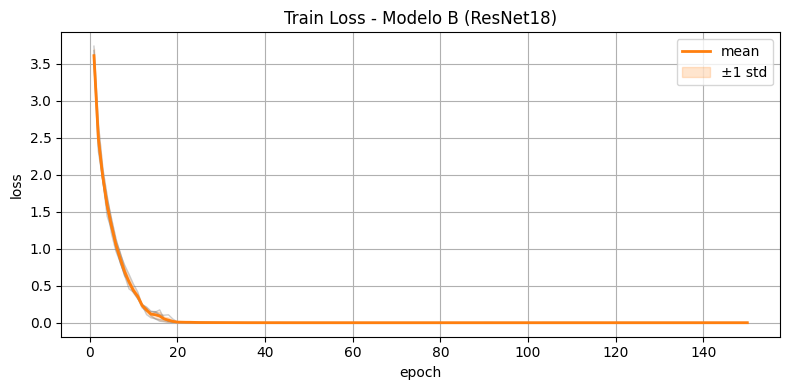

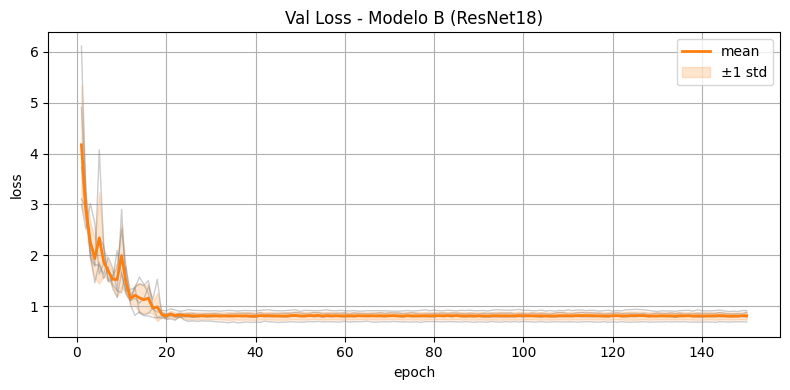

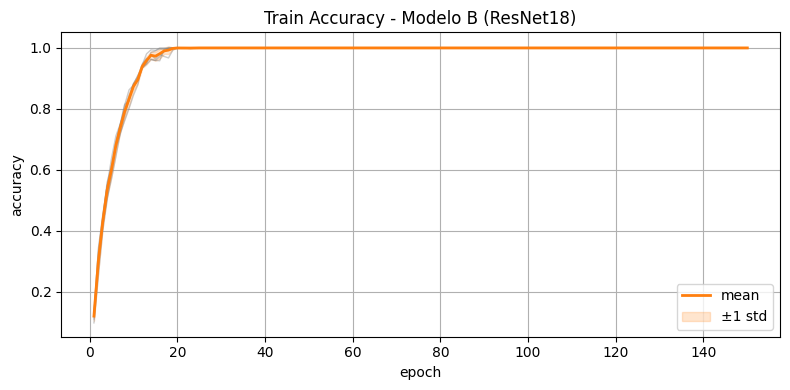

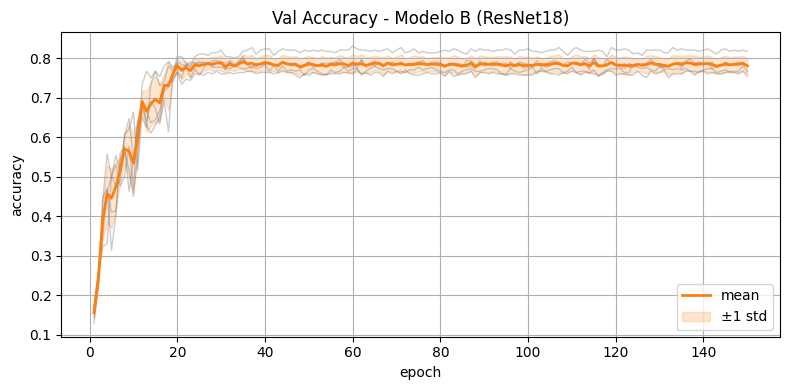

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import os

out_dir = "results_plots"
os.makedirs(out_dir, exist_ok=True)


histories_b = [r['history'] for r in results_b_base]
n_runs_b = len(histories_b)
epochs_b = len(histories_b[0]['train_loss'])

train_loss_b = np.array([h['train_loss'] for h in histories_b])
val_loss_b   = np.array([h['val_loss'] for h in histories_b])
train_acc_b  = np.array([h['train_acc'] for h in histories_b])
val_acc_b    = np.array([h['val_acc'] for h in histories_b])
x_b = np.arange(1, epochs_b+1)

def plot_with_mean_b(ax, arr, title, ylabel, filename):
    for row in arr:
        ax.plot(x_b, row, color='gray', alpha=0.4, linewidth=1)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(x_b, mean, color='tab:orange', linewidth=2, label='mean')
    ax.fill_between(x_b, mean-std, mean+std, color='tab:orange', alpha=0.2, label='±1 std')
    ax.set_title(title)
    ax.set_xlabel('epoch')
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, filename), dpi=150)

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean_b(ax, train_loss_b, "Train Loss - Modelo B (ResNet18)", "loss", "train_loss_resnet_b.png")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean_b(ax, val_loss_b, "Val Loss - Modelo B (ResNet18)", "loss", "val_loss_resnet_b.png")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean_b(ax, train_acc_b, "Train Accuracy - Modelo B (ResNet18)", "accuracy", "train_acc_resnet_b.png")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean_b(ax, val_acc_b, "Val Accuracy - Modelo B (ResNet18)", "accuracy", "val_acc_resnet_b.png")
plt.show()


## Modelo B aumentado

In [ ]:
#Ejecutar 5 experimentos con ResNet-18 (datos aumentados)

aggregate_b_aug = []
n_runs = 5
for i in range(n_runs):
    seed = 42 + i
    run_name = f"resnet_b_aug_run{i+1}_s{seed}"
    out = run_experiment_resnet(
        data_dir="spectrograms_split_224",
        output_dir="results_resnet_b_aug",
        run_name=run_name,
        num_classes=50,
        epochs=150,
        batch_size=32,
        lr=1e-3,
        weight_decay=1e-5,
        augmented=True,
        seed=seed,
        device="cuda"
    )
    aggregate_b_aug.append(out)


results_b_aug = aggregate_b_aug
print("Entrenamiento completado: Modelo B (ResNet18) con datos aumentados")


[Run resnet_b_aug_run1_s42] Device: cuda | Augmented: True | Seed: 42
[Run resnet_b_aug_run1_s42] Classes: 50 | Train: 1400 | Val: 300 | Test: 300
[resnet_b_aug_run1_s42] Epoch 1/150 | Train loss: 3.6796 acc: 0.1114 | Val loss: 3.4845 acc: 0.1767
[resnet_b_aug_run1_s42] Epoch 1/150 | Train loss: 3.6796 acc: 0.1114 | Val loss: 3.4845 acc: 0.1767
[resnet_b_aug_run1_s42] Epoch 2/150 | Train loss: 2.7798 acc: 0.2264 | Val loss: 2.9467 acc: 0.2233
[resnet_b_aug_run1_s42] Epoch 2/150 | Train loss: 2.7798 acc: 0.2264 | Val loss: 2.9467 acc: 0.2233
[resnet_b_aug_run1_s42] Epoch 3/150 | Train loss: 2.4843 acc: 0.3014 | Val loss: 3.1726 acc: 0.2600
[resnet_b_aug_run1_s42] Epoch 3/150 | Train loss: 2.4843 acc: 0.3014 | Val loss: 3.1726 acc: 0.2600
[resnet_b_aug_run1_s42] Epoch 4/150 | Train loss: 2.0561 acc: 0.4121 | Val loss: 2.2105 acc: 0.3833
[resnet_b_aug_run1_s42] Epoch 4/150 | Train loss: 2.0561 acc: 0.4121 | Val loss: 2.2105 acc: 0.3833
[resnet_b_aug_run1_s42] Epoch 5/150 | Train loss: 1.8

Gráficas guardadas en: results_resnet_b_aug\plots_resnet_b_augmented_history.png


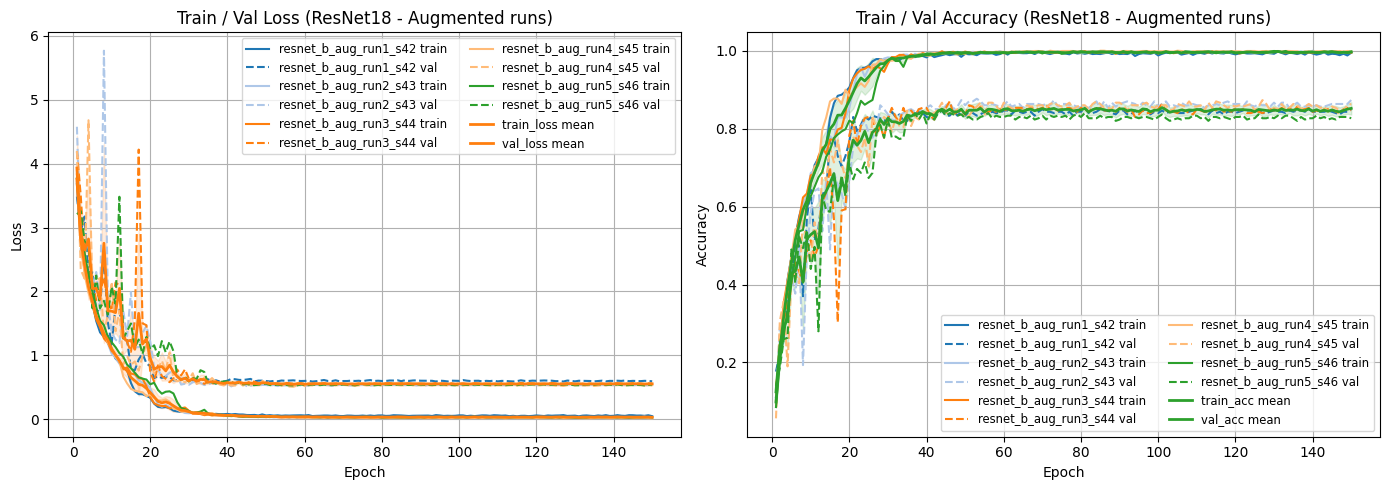

In [ ]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import torch

OUT_DIR = "results_resnet_b_aug"

def load_history_file(path):
    try:
        if path.endswith(".json"):
            with open(path, "r") as f:
                return json.load(f)
        if path.endswith(".npy") or path.endswith(".npz"):
            arr = np.load(path, allow_pickle=True)
            try:
                return arr.tolist()
            except Exception:
                return {k: arr[k].tolist() for k in arr.files}
        if path.endswith(".pth") or path.endswith(".pt"):
            d = torch.load(path, map_location="cpu")
            if isinstance(d, dict):
                if "history" in d and isinstance(d["history"], dict):
                    return d["history"]
                for k in ("train_loss","val_loss","train_acc","val_acc"):
                    if k in d:
                        return {k: d[k] for k in ("train_loss","val_loss","train_acc","val_acc") if k in d}
    except Exception:
        return None
    return None

def load_histories_from_disk(out_dir):
    histories = {}
    for p in glob.glob(os.path.join(out_dir, "**", "*history*.*"), recursive=True):
        h = load_history_file(p)
        if isinstance(h, dict) and h:
            histories[os.path.basename(p)] = h
    for p in glob.glob(os.path.join(out_dir, "best_*.pth")) + glob.glob(os.path.join(out_dir, "**", "best_*.pth"), recursive=True):
        h = load_history_file(p)
        if isinstance(h, dict) and h:
            histories[os.path.basename(p)] = h
    return histories

runs_list = None
if "aggregate_b_aug" in globals() and isinstance(globals()["aggregate_b_aug"], list) and globals()["aggregate_b_aug"]:
    runs_list = globals()["aggregate_b_aug"]
elif "results_b_aug" in globals() and isinstance(globals()["results_b_aug"], list) and globals()["results_b_aug"]:
    runs_list = globals()["results_b_aug"]

if runs_list is None:
    loaded = load_histories_from_disk(OUT_DIR)
    if loaded:
        runs_list = []
        for name, h in loaded.items():
            runs_list.append({"run_name": name, "history": h})
    else:
        print("No se encontraron resultados en memoria ni historiales en disco.")
        print("Ejecuta antes las corridas (variable `aggregate_b_aug` o `results_b_aug`)")
        raise SystemExit

normalized = []
for r in runs_list:
    if isinstance(r, dict) and "history" in r:
        h = r["history"]
        name = r.get("run_name", "run")
    elif isinstance(r, dict) and all(k in r for k in ("train_loss","val_loss","train_acc","val_acc")):
        h = {k: r[k] for k in ("train_loss","val_loss","train_acc","val_acc")}
        name = r.get("run_name","run")
    else:
        h = r if isinstance(r, dict) else {}
        name = "run"
    for k in ("train_loss","val_loss","train_acc","val_acc"):
        if k in h:
            try:
                h[k] = np.array(h[k], dtype=float)
            except Exception:
                h[k] = np.array(list(h[k]), dtype=float) if hasattr(h[k], "__iter__") else np.array([float(h[k])])
    normalized.append({"run_name": name, "history": h})

plt.rcParams.update({"figure.max_open_warning": 0})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
colors = plt.cm.tab20.colors
same_length = True
lengths = []

for idx, r in enumerate(normalized):
    h = r["history"]
    name = r["run_name"]
    c = colors[idx % len(colors)]
    # Loss
    if "train_loss" in h and "val_loss" in h:
        ax1.plot(np.arange(1, len(h["train_loss"])+1), h["train_loss"], label=f"{name} train", color=c, linestyle='-')
        ax1.plot(np.arange(1, len(h["val_loss"])+1), h["val_loss"], label=f"{name} val", color=c, linestyle='--')
        lengths.append(len(h["train_loss"]))
    else:
        if "train_loss" in h:
            ax1.plot(np.arange(1, len(h["train_loss"])+1), h["train_loss"], label=f"{name} train", color=c, linestyle='-')
            lengths.append(len(h["train_loss"]))
        if "val_loss" in h:
            ax1.plot(np.arange(1, len(h["val_loss"])+1), h["val_loss"], label=f"{name} val", color=c, linestyle='--')
            lengths.append(len(h["val_loss"]))
    if "train_acc" in h and "val_acc" in h:
        ax2.plot(np.arange(1, len(h["train_acc"])+1), h["train_acc"], label=f"{name} train", color=c, linestyle='-')
        ax2.plot(np.arange(1, len(h["val_acc"])+1), h["val_acc"], label=f"{name} val", color=c, linestyle='--')
    else:
        if "train_acc" in h:
            ax2.plot(np.arange(1, len(h["train_acc"])+1), h["train_acc"], label=f"{name} train", color=c, linestyle='-')
        if "val_acc" in h:
            ax2.plot(np.arange(1, len(h["val_acc"])+1), h["val_acc"], label=f"{name} val", color=c, linestyle='--')

if len(lengths) > 1 and len(set(lengths)) != 1:
    same_length = False

if same_length and lengths:
    L = lengths[0]
    def collect(key):
        arrs = []
        for r in normalized:
            h = r["history"]
            if key in h and len(h[key]) == L:
                arrs.append(h[key])
        return np.vstack(arrs) if arrs else None
    for key, ax, ylabel, title in [
        ("train_loss", ax1, "Loss", "Train Loss (runs)"),
        ("val_loss", ax1, "Loss", "Validation Loss (runs)"),
        ("train_acc", ax2, "Accuracy", "Train Acc (runs)"),
        ("val_acc", ax2, "Accuracy", "Val Acc (runs)"),
    ]:
        mat = collect(key)
        if mat is not None and mat.shape[0] >= 2:
            mean = mat.mean(axis=0)
            std = mat.std(axis=0)
            epochs = np.arange(1, L+1)
            alpha = 0.15
            if "loss" in key:
                ax.fill_between(epochs, mean-std, mean+std, color='tab:orange', alpha=alpha)
                ax.plot(epochs, mean, color='tab:orange', linewidth=2, label=f"{key} mean")
            else:
                ax.fill_between(epochs, mean-std, mean+std, color='tab:green', alpha=alpha)
                ax.plot(epochs, mean, color='tab:green', linewidth=2, label=f"{key} mean")

ax1.set_title("Train / Val Loss (ResNet18 - Augmented runs)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)
ax1.legend(fontsize='small', ncol=2)

ax2.set_title("Train / Val Accuracy (ResNet18 - Augmented runs)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
ax2.legend(fontsize='small', ncol=2)

plt.tight_layout()

os.makedirs(OUT_DIR, exist_ok=True)
plot_path = os.path.join(OUT_DIR, "plots_resnet_b_augmented_history.png")
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
print("Gráficas guardadas en:", plot_path)
plt.show()